#Image segmentation using unet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from  torchvision import transforms

from tqdm import tqdm

In [ ]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
print(device)

cuda:0


## Downloading dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dansbecker/cityscapes-image-pairs")
path

Using Colab cache for faster access to the 'cityscapes-image-pairs' dataset.


'/kaggle/input/cityscapes-image-pairs'

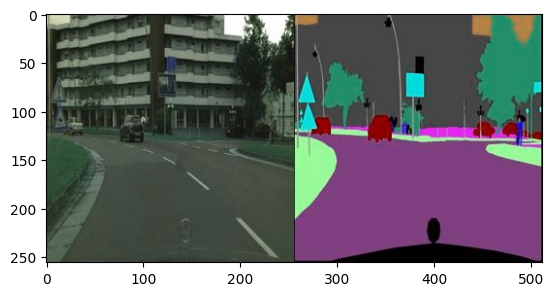

In [ ]:
plt.imshow(cv2.imread(f'{path}/cityscapes_data/train/1.jpg'))

In [ ]:
train_path = path + "/cityscapes_data/train"
val_path = path + "/cityscapes_data/val"

In [ ]:
train_fns = os.listdir(train_path)
val_fns = os.listdir(val_path)

In [ ]:
print('train:', len(train_fns), sep="->")
print('val:', len(val_fns), sep="->")

train:->2975
val:->500


## Data **analysis**

(256, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(255.5), np.float64(-0.5))

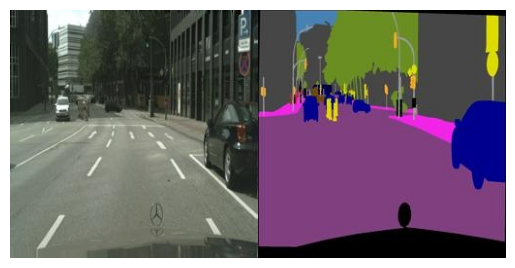

In [ ]:
sample_img = os.path.join(train_path, train_fns[0])
sample_img = cv2.imread(sample_img)
print(sample_img.shape)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.axis('off')

- Each file is a composite with the original photo on the left half of the image, alongside the labeled image (output of semantic segmentation) on the right half.
- As total width is 512 we'll spit each image from middle (0-255) data and (256-511) label

In [ ]:
def split_img(image):
  image = np.array(image)
  data, label = image[:,:256,:], image[:,256:, :]
  return data, label

(256, 512, 3)
data:->(256, 256, 3)
label:->(256, 256, 3)


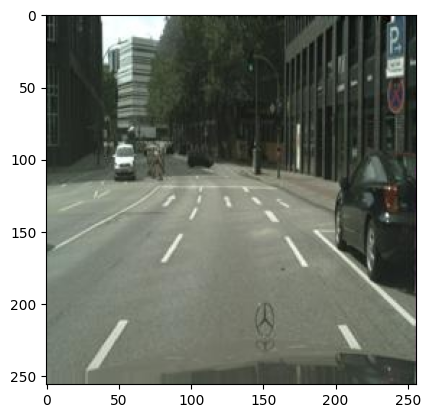

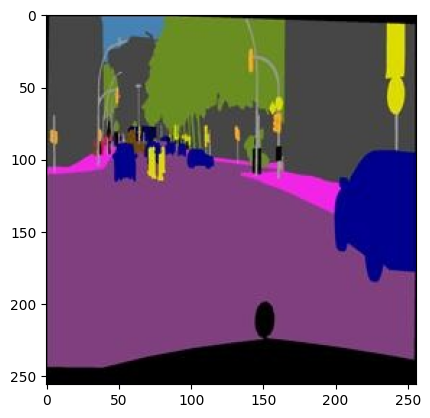

In [ ]:
sample_img_temp = np.array(sample_img)
print(sample_img_temp.shape)
data, lable = split_img(sample_img)
print("data:", data.shape, sep="->")
print("label:", lable.shape, sep="->")

plt.imshow(data)
plt.show()
plt.imshow(lable)
plt.show()

- Dataset: The dataset used is "dansbecker/cityscapes-image-pairs" from Kagglehub. This dataset contains images from the Cityscapes dataset.
- Dataset Structure: Each image file is a composite, with the original photo on the left half and a corresponding labeled image (ground truth for segmentation) on the right half. The original images are 256x256 pixels, and when combined with their labels, they become 256x512.

## Defining Labels

In [ ]:
color_set = set()
for train_fn in tqdm(train_fns[:10]):
    train_fp = os.path.join(train_path, train_fn)
    image = np.array(cv2.imread(train_fp))
    cityscape, label = split_img(sample_img)
    label = label.reshape(-1, 3)
    local_color_set = set([tuple(c) for c in list(label)])
    color_set.update(local_color_set)
color_array = np.array(list(color_set))

100%|██████████| 10/10 [00:01<00:00,  9.44it/s]


In [ ]:

num_items = 1000
color_array = np.random.choice(range(256), 3*num_items).reshape(-1, 3)
print(color_array.shape)
print(color_array[:5, :])

(1000, 3)
[[213 174  90]
 [ 78 241 122]
 [ 87 113 246]
 [ 96  91 252]
 [202  44  67]]


In [ ]:
label_model = KMeans(n_clusters=10)
label_model.fit(color_array)

KMeans(n_clusters=10)

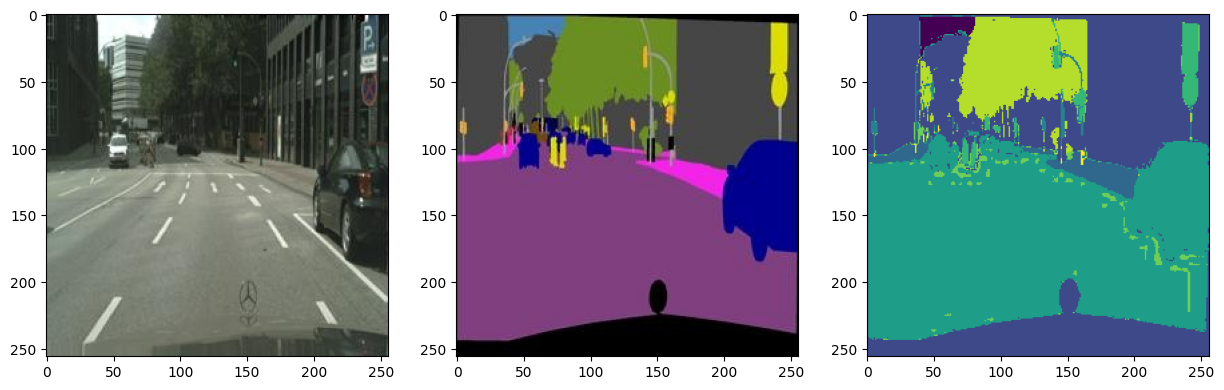

In [ ]:
cityscape, label = split_img(sample_img)
label_class = label_model.predict(label.reshape(-1, 3)).reshape(256, 256)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cityscape)
axes[1].imshow(label)
axes[2].imshow(label_class)

In [ ]:
print(label_class)

[[2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]]


In [ ]:
class CityscapeDataset(Dataset):

    def __init__(self, image_dir, label_model):
        self.image_dir = image_dir
        self.image_fns = os.listdir(image_dir)
        self.label_model = label_model

    def __len__(self):
        return len(self.image_fns)

    def __getitem__(self, index):
        image_fn = self.image_fns[index]
        image_fp = os.path.join(self.image_dir, image_fn)
        image = cv2.cvtColor(cv2.imread(image_fp), cv2.COLOR_BGR2RGB)
        image = np.array(image)
        cityscape, label = self.split_image(image)
        label_class = self.label_model.predict(label.reshape(-1, 3)).reshape(256, 256)
        cityscape = self.transform(cityscape)
        label_class = torch.Tensor(label_class).long()
        return cityscape, label_class

    def split_image(self, image):
        image = np.array(image)
        cityscape, label = image[:, :256, :], image[:, 256:, :]
        return cityscape, label

    def transform(self, image):
        transform_ops = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])
        return transform_ops(image)


In [ ]:
dataset = CityscapeDataset(train_path, label_model)
len(dataset)

2975

In [ ]:
data, label = dataset[0]
print(data.shape, label.shape)

torch.Size([3, 256, 256]) torch.Size([256, 256])


- Segmentation Type: The notebook performs semantic segmentation. This is evident because a KMeans model is used to cluster the colors in the labeled images into 10 distinct classes. This process assigns a class label to each pixel in the segmented image, categorizing them into predefined groups (e.g., road, building, sky, etc., represented by distinct colors).
- Reason Being: The goal is to train a U-Net model to predict these semantic labels. The KMeans clustering allows for the creation of a discrete set of target classes from the continuous color values found in the original labeled images, making it suitable for training a classification-based segmentation model.

## UNET Model

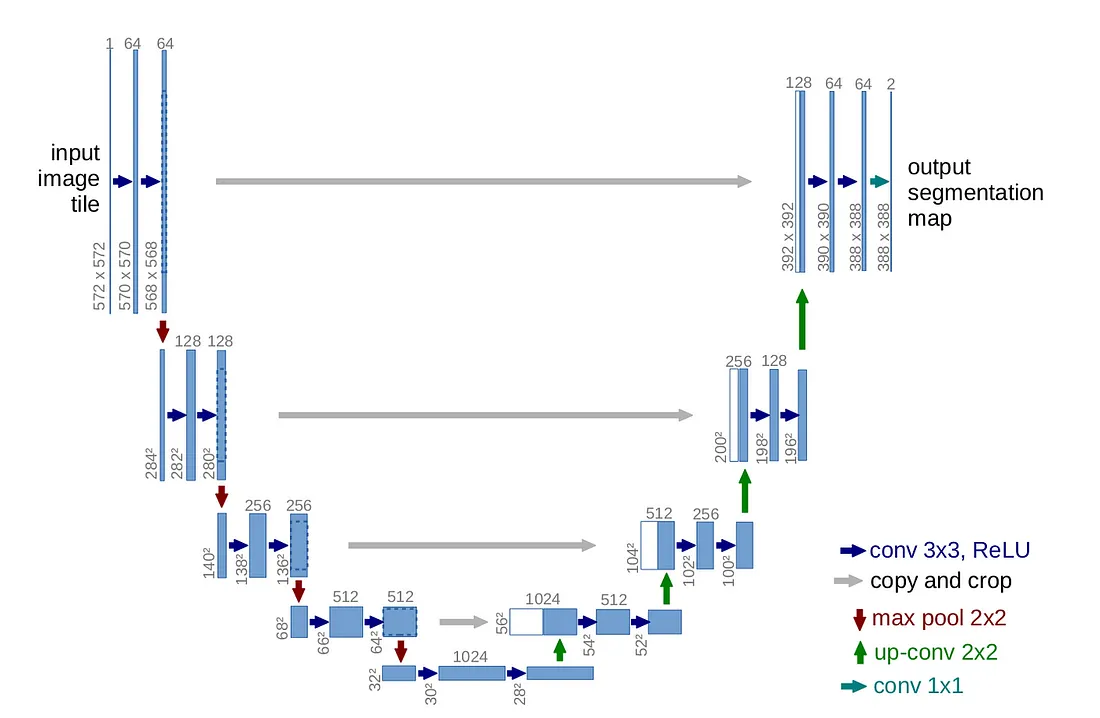

In [ ]:
class UNet(nn.Module):

    def __init__(self, num_classes):
        super(UNet, self).__init__()
        self.num_classes = num_classes
        self.contracting_11 = self.conv_block(in_channels=3, out_channels=64)
        self.contracting_12 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting_21 = self.conv_block(in_channels=64, out_channels=128)
        self.contracting_22 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting_31 = self.conv_block(in_channels=128, out_channels=256)
        self.contracting_32 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.contracting_41 = self.conv_block(in_channels=256, out_channels=512)
        self.contracting_42 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.middle = self.conv_block(in_channels=512, out_channels=1024)
        self.expansive_11 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.expansive_12 = self.conv_block(in_channels=1024, out_channels=512)
        self.expansive_21 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.expansive_22 = self.conv_block(in_channels=512, out_channels=256)
        self.expansive_31 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.expansive_32 = self.conv_block(in_channels=256, out_channels=128)
        self.expansive_41 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.expansive_42 = self.conv_block(in_channels=128, out_channels=64)
        self.output = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=3, stride=1, padding=1)

    def conv_block(self, in_channels, out_channels):
        block = nn.Sequential(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
                                    nn.ReLU(),
                                    nn.BatchNorm2d(num_features=out_channels),
                                    nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
                                    nn.ReLU(),
                                    nn.BatchNorm2d(num_features=out_channels))
        return block

    def forward(self, X):
        contracting_11_out = self.contracting_11(X) # [-1, 64, 256, 256]
        contracting_12_out = self.contracting_12(contracting_11_out) # [-1, 64, 128, 128]
        contracting_21_out = self.contracting_21(contracting_12_out) # [-1, 128, 128, 128]
        contracting_22_out = self.contracting_22(contracting_21_out) # [-1, 128, 64, 64]
        contracting_31_out = self.contracting_31(contracting_22_out) # [-1, 256, 64, 64]
        contracting_32_out = self.contracting_32(contracting_31_out) # [-1, 256, 32, 32]
        contracting_41_out = self.contracting_41(contracting_32_out) # [-1, 512, 32, 32]
        contracting_42_out = self.contracting_42(contracting_41_out) # [-1, 512, 16, 16]
        middle_out = self.middle(contracting_42_out) # [-1, 1024, 16, 16]
        expansive_11_out = self.expansive_11(middle_out) # [-1, 512, 32, 32]
        expansive_12_out = self.expansive_12(torch.cat((expansive_11_out, contracting_41_out), dim=1)) # [-1, 1024, 32, 32] -> [-1, 512, 32, 32]
        expansive_21_out = self.expansive_21(expansive_12_out) # [-1, 256, 64, 64]
        expansive_22_out = self.expansive_22(torch.cat((expansive_21_out, contracting_31_out), dim=1)) # [-1, 512, 64, 64] -> [-1, 256, 64, 64]
        expansive_31_out = self.expansive_31(expansive_22_out) # [-1, 128, 128, 128]
        expansive_32_out = self.expansive_32(torch.cat((expansive_31_out, contracting_21_out), dim=1)) # [-1, 256, 128, 128] -> [-1, 128, 128, 128]
        expansive_41_out = self.expansive_41(expansive_32_out) # [-1, 64, 256, 256]
        expansive_42_out = self.expansive_42(torch.cat((expansive_41_out, contracting_11_out), dim=1)) # [-1, 128, 256, 256] -> [-1, 64, 256, 256]
        output_out = self.output(expansive_42_out) # [-1, num_classes, 256, 256]
        return output_out



In [ ]:
model = UNet(num_classes=10)


In [ ]:
data_loader = DataLoader(dataset, batch_size=4)
print(len(dataset), len(data_loader))

X, Y = next(iter(data_loader))
print(X.shape, Y.shape)

2975 744
torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


In [ ]:
y_pred = model(X)
print(y_pred.shape)

torch.Size([4, 10, 256, 256])


## Training

In [ ]:
batch_size = 16
epochs = 10
lr = 0.01

In [ ]:
dataset = CityscapeDataset(train_path, label_model)
data_loader = DataLoader(dataset, batch_size=batch_size)

In [ ]:
model = UNet(num_classes=10).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [33]:
step_losses = []
epoch_losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for X, Y in tqdm(data_loader, total=len(data_loader), leave=False):
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        Y_pred = model(X)
        loss = criterion(Y_pred, Y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        step_losses.append(loss.item())
    epoch_losses.append(epoch_loss/len(data_loader))

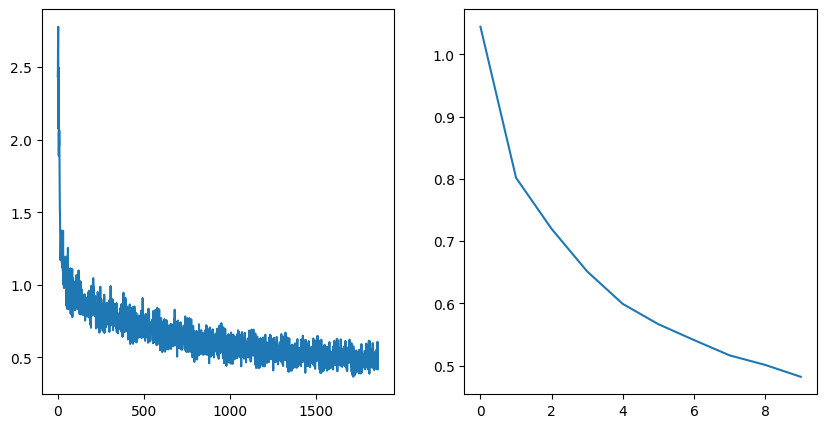

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(step_losses)
axes[1].plot(epoch_losses)

In [35]:
torch.save(model.state_dict(), "U-Net.pth")

## Model inferance

In [36]:
model_path = "./U-Net.pth"
model_ = UNet(num_classes=10).to(device)
model_.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [37]:
test_batch_size = 8
dataset = CityscapeDataset(val_path, label_model)
data_loader = DataLoader(dataset, batch_size=test_batch_size)

In [38]:
X, Y = next(iter(data_loader))
X, Y = X.to(device), Y.to(device)
Y_pred = model_(X)
print(Y_pred.shape)
Y_pred = torch.argmax(Y_pred, dim=1)
print(Y_pred.shape)

torch.Size([8, 10, 256, 256])
torch.Size([8, 256, 256])


In [39]:
inverse_transform = transforms.Compose([
    transforms.Normalize((-0.485/0.229, -0.456/0.224, -0.406/0.225), (1/0.229, 1/0.224, 1/0.225))])

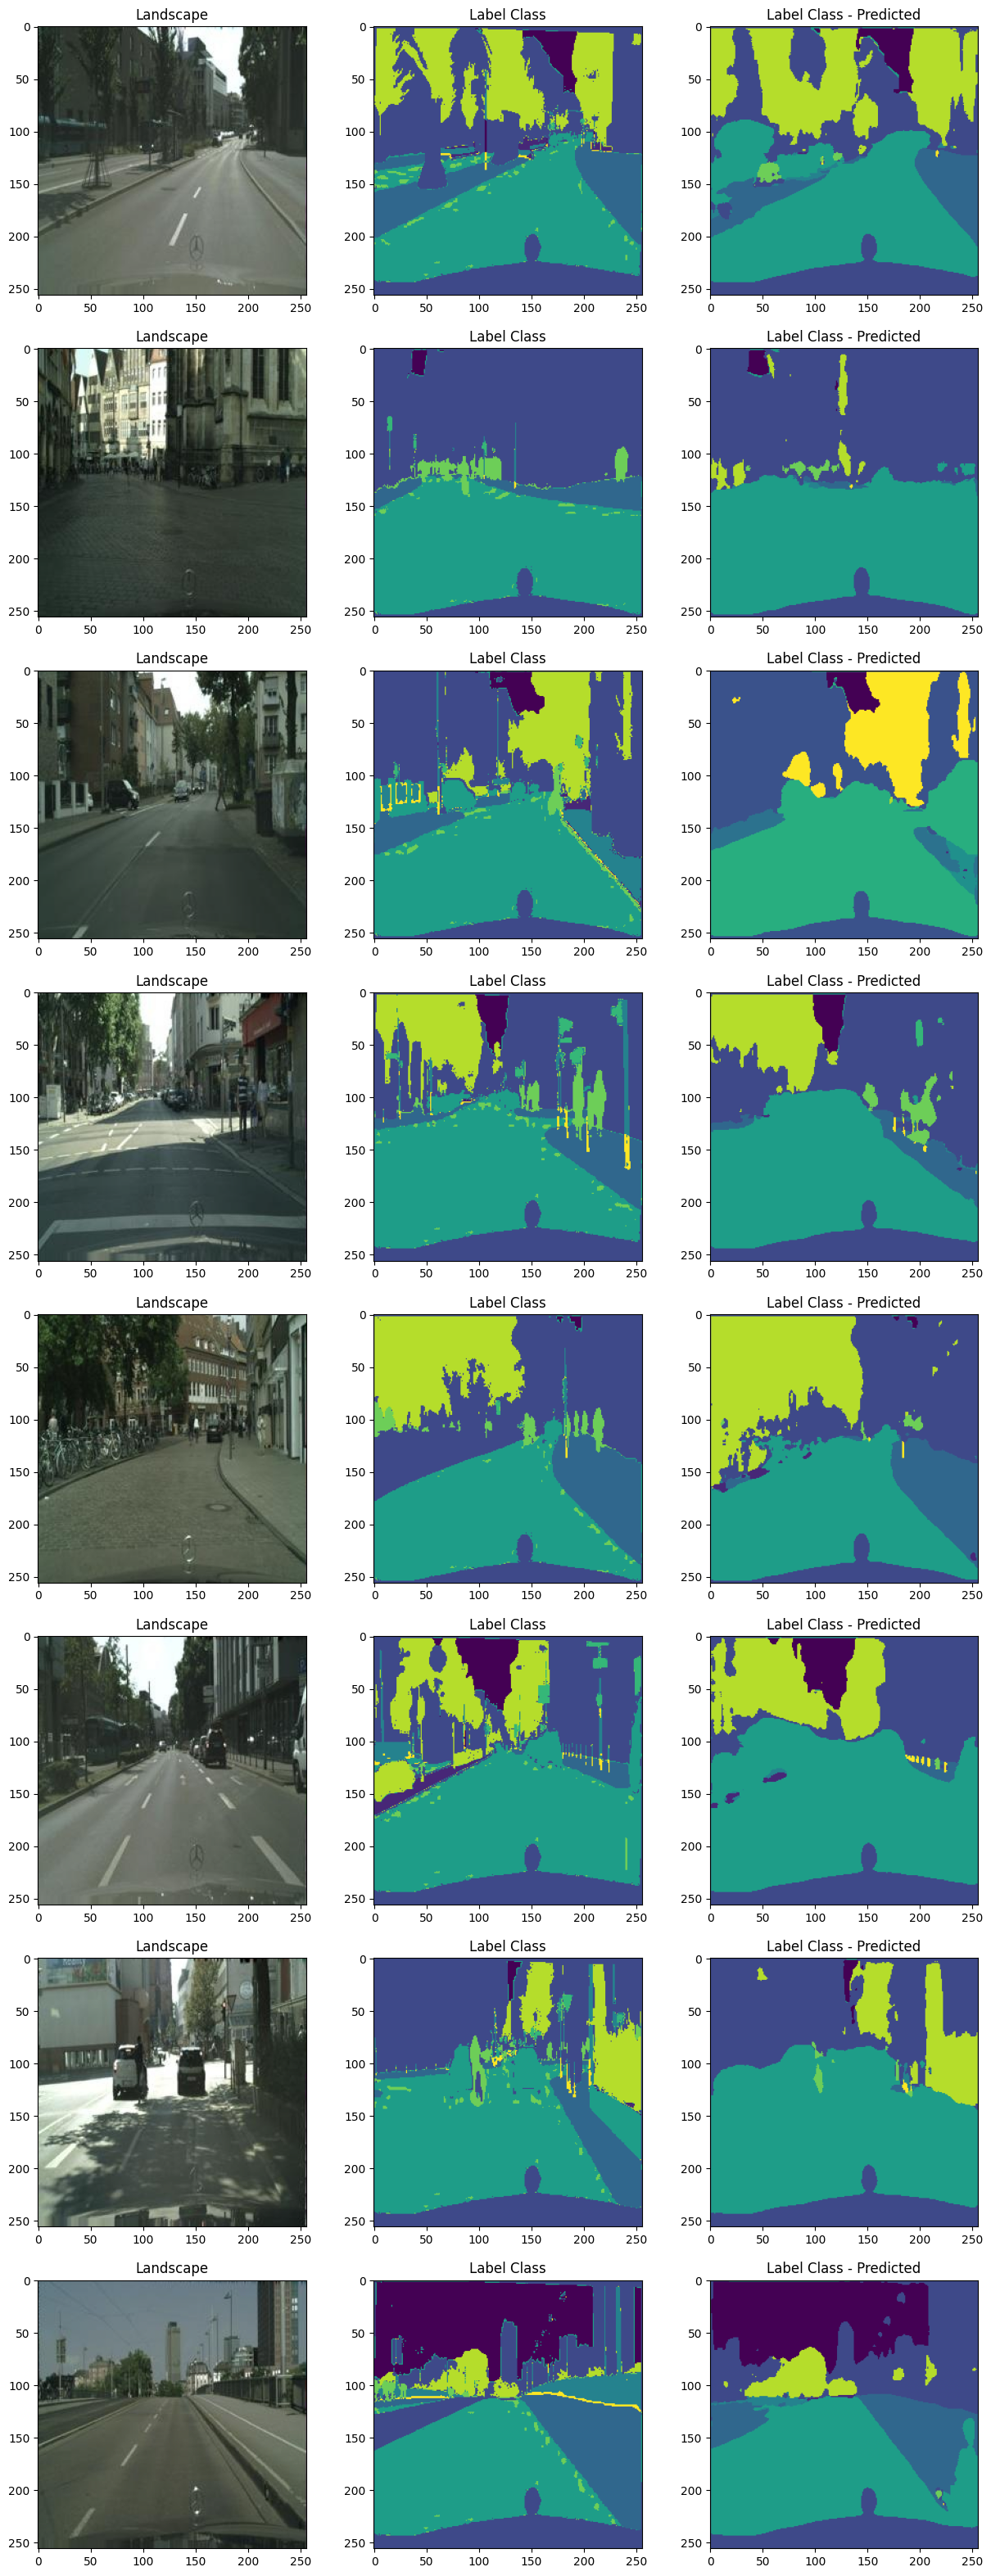

In [40]:
fig, axes = plt.subplots(test_batch_size, 3, figsize=(3*5, test_batch_size*5))

for i in range(test_batch_size):

    landscape = inverse_transform(X[i]).permute(1, 2, 0).cpu().detach().numpy()
    label_class = Y[i].cpu().detach().numpy()
    label_class_predicted = Y_pred[i].cpu().detach().numpy()

    axes[i, 0].imshow(landscape)
    axes[i, 0].set_title("Landscape")
    axes[i, 1].imshow(label_class)
    axes[i, 1].set_title("Label Class")
    axes[i, 2].imshow(label_class_predicted)
    axes[i, 2].set_title("Label Class - Predicted")